# DICOM to NPY Conversion: Patient Processing Pipeline

**Objetivo**: Convertir resonancia DICOM de paciente individual a formato .npy compatible con el modelo Swin Small.

**Entrada**:
- ZIP con serie DICOM: `data/2025-10-07-alberola-guillot-marc-rm-rodilla-izquierd.zip`

**Salida**:
- Volúmenes .npy por plano (sagittal, coronal, axial)
- Metadata JSON con información del paciente
- Compatible con Threshold_Tuning_and_External_Validation.ipynb

**Pipeline**:
1. Extraer DICOM del ZIP
2. Validar serie y leer metadata
3. Apilación de slices y creación de volumen 3D
4. Normalización 8-bit
5. Extracción de planos ortogonales
6. Guardar como NPY en estructura esperada

## 1. Setup & Imports

In [1]:
import os
import sys
import json
import zipfile
import numpy as np
import pandas as pd
import pydicom
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import tempfile
import shutil

warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, str(Path.cwd().parent))

# Paths
BASE_DIR = Path('..').resolve()
DATA_DIR = BASE_DIR / 'data'
DICOM_ZIP = DATA_DIR / '2025-10-07-alberola-guillot-marc-rm-rodilla-izquierd.zip'
OUTPUT_DIR = Path('./patient_volume')  # Will save next to this notebook

# Create output directories
PLANES = ['sagittal', 'coronal', 'axial']
for plane in PLANES:
    (OUTPUT_DIR / plane).mkdir(parents=True, exist_ok=True)

print(f" Setup complete")
print(f"  Input ZIP: {DICOM_ZIP}")
print(f"  Output dir: {OUTPUT_DIR}")
print(f"  Planes: {PLANES}")

 Setup complete
  Input ZIP: /home/palodo2/acl_classifier/data/2025-10-07-alberola-guillot-marc-rm-rodilla-izquierd.zip
  Output dir: patient_volume
  Planes: ['sagittal', 'coronal', 'axial']


## 2. Extract DICOM from ZIP

In [2]:
# Extract ZIP to temporary directory
temp_dicom_dir = Path(tempfile.mkdtemp(prefix='dicom_extract_'))
print(f"Extracting DICOM from ZIP to {temp_dicom_dir}...")

try:
    with zipfile.ZipFile(DICOM_ZIP, 'r') as zip_ref:
        zip_ref.extractall(temp_dicom_dir)

 # Weasis ZIPs often contain DICOMs without extension, so scan all files
        all_files = [f for f in temp_dicom_dir.rglob('*') if f.is_file()]
        dicom_files = []
        for item in all_files:
            try:
                pydicom.dcmread(str(item), stop_before_pixels=True, force=True)
                dicom_files.append(item)
            except Exception:
                pass

    print(f" Found {len(dicom_files)} DICOM-like files")
    if len(dicom_files) == 0:
        raise ValueError('No valid DICOM files were found in the ZIP archive')

    print(f"\nDirectory structure:")
    for item in dicom_files[:20]:
        print(f"  {item.relative_to(temp_dicom_dir)}")
    if len(dicom_files) > 20:
        print(f"  ... and {len(dicom_files) - 20} more")

except Exception as e:
    print(f" Error extracting ZIP: {e}")
    raise

Extracting DICOM from ZIP to /tmp/dicom_extract_cj3_vbkz...
 Found 594 DICOM-like files

Directory structure:
  weasis-portable/Licence.txt
  weasis-portable/Readme.txt
  weasis-portable/DICOMDIR
  weasis-portable/viewer-win32.l4j.ini
  weasis-portable/Autorun.inf
  weasis-portable/viewer-win32.exe
  weasis-portable/viewer-linux.sh
  weasis-portable/DICOM/32
  weasis-portable/DICOM/64
  weasis-portable/DICOM/80
  weasis-portable/DICOM/98
  weasis-portable/DICOM/39
  weasis-portable/DICOM/93
  weasis-portable/DICOM/43
  weasis-portable/DICOM/87
  weasis-portable/DICOM/29
  weasis-portable/DICOM/65
  weasis-portable/DICOM/19
  weasis-portable/DICOM/82
  weasis-portable/DICOM/16
  ... and 574 more


## 3. Read DICOM Series and Validate

In [3]:
"""
Load and validate DICOM series
"""

# Read DICOM files
dicom_data = []
errors = []

for dcm_file in sorted(dicom_files)[:200]:  # Limit to first 200 files
    try:
        ds = pydicom.dcmread(dcm_file, force=True)

 # Extract key metadata
        slice_info = {
            'file': dcm_file,
            'slice_location': float(ds.SliceLocation) if hasattr(ds, 'SliceLocation') else None,
            'instance_number': int(ds.InstanceNumber) if hasattr(ds, 'InstanceNumber') else None,
            'rows': int(ds.Rows),
            'columns': int(ds.Columns),
            'bits_allocated': int(ds.BitsAllocated),
            'pixel_array': ds.pixel_array
        }
        dicom_data.append(slice_info)
    except Exception as e:
        errors.append((dcm_file.name, str(e)))

if len(dicom_data) == 0:
    raise ValueError('No valid DICOM slices were decoded from the ZIP archive. Check the archive contents.')

print(f" Successfully read {len(dicom_data)} DICOM files")
if errors:
    print(f" Errors reading {len(errors)} files:")
    for fname, err in errors[:5]:
        print(f"  - {fname}: {err[:60]}")

# Validate series consistency
if dicom_data:
    print(f"\nSeries Metadata:")
    print(f"  Rows: {dicom_data[0]['rows']}")
    print(f"  Columns: {dicom_data[0]['columns']}")
    print(f"  Bits allocated: {dicom_data[0]['bits_allocated']}")
    print(f"  Number of slices: {len(dicom_data)}")

 # Check if all slices have same dimensions
    rows_set = set(d['rows'] for d in dicom_data)
    cols_set = set(d['columns'] for d in dicom_data)

    if len(rows_set) == 1 and len(cols_set) == 1:
        print(f"   All slices have consistent dimensions")
    else:
        print(f"   Inconsistent dimensions: Rows {rows_set}, Cols {cols_set}")

 Successfully read 114 DICOM files
 Errors reading 86 files:
  - Autorun.inf: 'FileDataset' object has no attribute 'Rows'
  - 116: 'FileDataset' object has no attribute 'Rows'
  - DICOMDIR: 'DicomDir' object has no attribute 'Rows'
  - Licence.txt: 'FileDataset' object has no attribute 'Rows'
  - Readme.txt: 'FileDataset' object has no attribute 'Rows'

Series Metadata:
  Rows: 512
  Columns: 512
  Bits allocated: 16
  Number of slices: 114
   All slices have consistent dimensions


## 4. Stack Slices and Create 3D Volume

In [4]:
"""
Create 3D volume from stacked 2D slices.
Order by SliceLocation or InstanceNumber
"""

# Sort by slice location (z-axis position)
if all(d['slice_location'] is not None for d in dicom_data):
    dicom_data.sort(key=lambda x: x['slice_location'])
    sort_method = 'SliceLocation'
else:
    dicom_data.sort(key=lambda x: x['instance_number'])
    sort_method = 'InstanceNumber'

print(f"Sorted by: {sort_method}")

# Stack pixel arrays into 3D volume
slices_array = [d['pixel_array'] for d in dicom_data]
volume_3d = np.stack(slices_array, axis=0)  # (depth, height, width)

print(f"\n3D Volume created:")
print(f"  Shape (D, H, W): {volume_3d.shape}")
print(f"  Data type: {volume_3d.dtype}")
print(f"  Value range: [{volume_3d.min()}, {volume_3d.max()}]")
print(f"  Bits used: {int(volume_3d.max()).bit_length()}")

Sorted by: SliceLocation

3D Volume created:
  Shape (D, H, W): (114, 512, 512)
  Data type: int16
  Value range: [0, 2000]
  Bits used: 11


## 5. Normalize to 8-bit (0-255)

In [5]:
"""
Normalize volume to 8-bit range (0-255).
This matches the normalization used in Croatia dataset.
"""

# Convert to float for normalization
volume_float = volume_3d.astype(np.float32)

# Min-max normalization to [0, 1]
v_min = volume_float.min()
v_max = volume_float.max()

print(f"Original value range: [{v_min:.1f}, {v_max:.1f}]")

if v_max > v_min:
    volume_normalized = (volume_float - v_min) / (v_max - v_min)
else:
    volume_normalized = volume_float
    print(" Warning: all pixel values are the same!")

# Scale to [0, 255] and convert to uint8
volume_8bit = (volume_normalized * 255).astype(np.uint8)

print(f"\n Normalized to 8-bit:")
print(f"  Shape: {volume_8bit.shape}")
print(f"  Data type: {volume_8bit.dtype}")
print(f"  Value range: [{volume_8bit.min()}, {volume_8bit.max()}]")

Original value range: [0.0, 2000.0]

 Normalized to 8-bit:
  Shape: (114, 512, 512)
  Data type: uint8
  Value range: [0, 255]


## 6. Extract Orthogonal Planes

In [6]:
"""
Extract sagittal, coronal, and axial planes from the 3D volume.

Assuming volume orientation (D, H, W) representing (Z, Y, X) in medical coords:
- Sagittal: XZ plane (left-right view)  volume[:, :, x] for each x
- Coronal: YZ plane (front-back view)  volume[:, y, :] for each y
- Axial: XY plane (top-bottom view)  volume[z, :, :] for each z

We'll take all slices and create plane-specific volumes.
"""

print("Extracting orthogonal planes...")

# Define planes
planes_volumes = {}

# Sagittal: all X slices shape (depth=W, height=D, width=H)
sagittal_slices = []
for x in range(volume_8bit.shape[2]):  # For each X position
    slice_xz = volume_8bit[:, :, x]  # Get Z-Y cross-section at position X
    sagittal_slices.append(slice_xz)
volume_sagittal = np.stack(sagittal_slices, axis=0)  # (X_slices, D, H)

# Coronal: all Y slices shape (depth=W, height=D, width=Y)
coronal_slices = []
for y in range(volume_8bit.shape[1]):  # For each Y position
    slice_yz = volume_8bit[:, y, :]  # Get Z-X cross-section at position Y
    coronal_slices.append(slice_yz)
volume_coronal = np.stack(coronal_slices, axis=0)  # (Y_slices, D, W)

# Axial: all Z slices shape (depth=Z, height=H, width=W)
volume_axial = volume_8bit  # Already in correct format (Z, H, W)

planes_volumes = {
    'sagittal': volume_sagittal,
    'coronal': volume_coronal,
    'axial': volume_axial
}

print(f"\n Planes extracted:")
for plane, vol in planes_volumes.items():
    print(f"  {plane:10s} shape: {vol.shape}")
    print(f"              dtype: {vol.dtype}, range: [{vol.min()}, {vol.max()}]")

Extracting orthogonal planes...



 Planes extracted:
  sagittal   shape: (512, 114, 512)
              dtype: uint8, range: [0, 255]
  coronal    shape: (512, 114, 512)
              dtype: uint8, range: [0, 255]
  axial      shape: (114, 512, 512)
              dtype: uint8, range: [0, 255]


## 7. Save Plane Volumes as NPY

In [7]:
"""
Save each plane volume as individual .npy files.
File structure: plane/0001.npy (case_id = 1 for single patient)
"""

CASE_ID = 1
case_id_str = f"{CASE_ID:04d}"

print(f"Saving plane volumes (case_id: {case_id_str})...")

saved_files = {}

for plane, volume in planes_volumes.items():
    output_file = OUTPUT_DIR / plane / f"{case_id_str}.npy"
    np.save(str(output_file), volume)
    saved_files[plane] = output_file
    print(f"   Saved {plane:10s}: {output_file.name}")
    print(f"     Shape: {volume.shape}, Size: {volume.nbytes / 1024 / 1024:.1f} MB")

print(f"\n All planes saved to {OUTPUT_DIR}")

Saving plane volumes (case_id: 0001)...
   Saved sagittal  : 0001.npy
     Shape: (512, 114, 512), Size: 28.5 MB
   Saved coronal   : 0001.npy
     Shape: (512, 114, 512), Size: 28.5 MB
   Saved axial     : 0001.npy
     Shape: (114, 512, 512), Size: 28.5 MB

 All planes saved to patient_volume


## 8. Save Metadata

In [8]:
"""
Save patient metadata for reference and future analysis.
"""

# Try to extract patient info from DICOM
patient_info = {}
if dicom_data and hasattr(dicom_data[0]['pixel_array'], '__len__'):
 # Use first slice's DICOM file to get metadata
    try:
        ds_meta = pydicom.dcmread(dicom_data[0]['file'])
        patient_info = {
            'patient_name': str(ds_meta.PatientName) if hasattr(ds_meta, 'PatientName') else 'Unknown',
            'patient_id': str(ds_meta.PatientID) if hasattr(ds_meta, 'PatientID') else 'Unknown',
            'patient_age': str(ds_meta.PatientAge) if hasattr(ds_meta, 'PatientAge') else 'Unknown',
            'patient_sex': str(ds_meta.PatientSex) if hasattr(ds_meta, 'PatientSex') else 'Unknown',
            'study_date': str(ds_meta.StudyDate) if hasattr(ds_meta, 'StudyDate') else 'Unknown',
            'modality': str(ds_meta.Modality) if hasattr(ds_meta, 'Modality') else 'MR',
            'body_part': str(ds_meta.BodyPartExamined) if hasattr(ds_meta, 'BodyPartExamined') else 'Unknown',
        }
    except:
        patient_info = {'error': 'Could not extract metadata from DICOM'}

# Create metadata dictionary
metadata = {
    'case_id': CASE_ID,
    'timestamp': datetime.now().isoformat(),
    'source': 'Patient DICOM MRI',
    'volume_shape_original': volume_3d.shape,
    'volume_shape_normalized': volume_8bit.shape,
    'normalization': {
        'method': 'min-max to 8-bit',
        'original_min': float(v_min),
        'original_max': float(v_max),
        'target_range': [0, 255]
    },
    'planes': {
        plane: {
            'shape': list(vol.shape),
            'dtype': str(vol.dtype),
            'min': int(vol.min()),
            'max': int(vol.max())
        }
        for plane, vol in planes_volumes.items()
    },
    'dicom_info': {
        'num_slices': len(dicom_data),
        'slice_height': int(dicom_data[0]['rows']) if dicom_data else None,
        'slice_width': int(dicom_data[0]['columns']) if dicom_data else None,
        'bits_allocated': int(dicom_data[0]['bits_allocated']) if dicom_data else None,
        'sort_method': sort_method
    },
    'patient_info': patient_info
}

# Save as JSON
metadata_file = OUTPUT_DIR / 'metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f" Metadata saved: {metadata_file}")

# Also create CSV for compatibility with data loader
metadata_csv = OUTPUT_DIR / 'metadata.csv'
df_meta = pd.DataFrame([{
    'case_id': CASE_ID,
    'patient_name': patient_info.get('patient_name', 'Unknown'),
    'patient_id': patient_info.get('patient_id', 'Unknown'),
    'study_date': patient_info.get('study_date', 'Unknown'),
    'body_part': patient_info.get('body_part', 'Unknown'),
    'sagittal_shape': str(planes_volumes['sagittal'].shape),
    'coronal_shape': str(planes_volumes['coronal'].shape),
    'axial_shape': str(planes_volumes['axial'].shape)
}])
df_meta.to_csv(metadata_csv, index=False)

print(f" CSV metadata saved: {metadata_csv}")
print(f"\nPatient Info:")
for key, value in patient_info.items():
    print(f"  {key}: {value}")

 Metadata saved: patient_volume/metadata.json
 CSV metadata saved: patient_volume/metadata.csv

Patient Info:
  patient_name: ALBEROLA GUILLOT^MARC
  patient_id: 50393
  patient_age: 023Y
  patient_sex: M
  study_date: 20251007
  modality: MR
  body_part: KNEE


## 9. Validation and Summary

In [9]:
"""
Validate that created .npy files match expected format for the model.
"""

print("="*80)
print("VALIDATION: Checking compatibility with model")
print("="*80)

# Check file existence
print("\n1. File Structure:")
for plane in PLANES:
    npy_file = OUTPUT_DIR / plane / f"{case_id_str}.npy"
    if npy_file.exists():
        print(f"   {plane:10s}/0001.npy exists")
    else:
        print(f"   {plane:10s}/0001.npy NOT FOUND")

# Validate shapes
print("\n2. Volume Shapes (expected: (depth, height, width)):")
for plane in PLANES:
    npy_file = OUTPUT_DIR / plane / f"{case_id_str}.npy"
    if npy_file.exists():
        loaded_vol = np.load(npy_file)
        print(f"  {plane:10s}: {loaded_vol.shape}")

# Check value ranges
print("\n3. Value Ranges (should be 0-255):")
for plane in PLANES:
    npy_file = OUTPUT_DIR / plane / f"{case_id_str}.npy"
    if npy_file.exists():
        loaded_vol = np.load(npy_file)
        print(f"  {plane:10s}: [{loaded_vol.min()}, {loaded_vol.max()}]")

# Check file sizes
print("\n4. File Sizes:")
total_size = 0
for plane in PLANES:
    npy_file = OUTPUT_DIR / plane / f"{case_id_str}.npy"
    if npy_file.exists():
        size_mb = npy_file.stat().st_size / 1024 / 1024
        total_size += size_mb
        print(f"  {plane:10s}: {size_mb:.1f} MB")
print(f"  Total: {total_size:.1f} MB")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f" Conversion complete!")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Case ID: {CASE_ID}")
print(f"  Ready to use with Threshold_Tuning_and_External_Validation.ipynb")
print(f"\nNext steps:")
print(f"  1. Review metadata in {metadata_file}")
print(f"  2. Verify planes look correct (you can visualize with jupyter)")
print(f"  3. Use paths: {OUTPUT_DIR}/[sagittal|coronal|axial]/0001.npy")
print("="*80)

VALIDATION: Checking compatibility with model

1. File Structure:
   sagittal  /0001.npy exists
   coronal   /0001.npy exists
   axial     /0001.npy exists

2. Volume Shapes (expected: (depth, height, width)):
  sagittal  : (512, 114, 512)
  coronal   : (512, 114, 512)
  axial     : (114, 512, 512)

3. Value Ranges (should be 0-255):
  sagittal  : [0, 255]
  coronal   : [0, 255]
  axial     : [0, 255]

4. File Sizes:
  sagittal  : 28.5 MB
  coronal   : 28.5 MB
  axial     : 28.5 MB
  Total: 85.5 MB

SUMMARY
 Conversion complete!
  Output directory: patient_volume
  Case ID: 1
  Ready to use with Threshold_Tuning_and_External_Validation.ipynb

Next steps:
  1. Review metadata in patient_volume/metadata.json
  2. Verify planes look correct (you can visualize with jupyter)
  3. Use paths: patient_volume/[sagittal|coronal|axial]/0001.npy


## 10. Optional: Clean Up Temporary Files

In [10]:
"""
Remove temporary DICOM extraction directory.
Set cleanup_temp = True to remove temporary files.
"""

cleanup_temp = False  # Change to True when ready to cleanup

if cleanup_temp:
    try:
        shutil.rmtree(temp_dicom_dir)
        print(f" Cleaned up temporary directory: {temp_dicom_dir}")
    except Exception as e:
        print(f" Error cleaning up: {e}")
else:
    print(f"Temporary DICOM directory (for reference): {temp_dicom_dir}")
    print(f"To delete, set cleanup_temp = True in next run or manually:")
    print(f"  rm -rf {temp_dicom_dir}")

Temporary DICOM directory (for reference): /tmp/dicom_extract_cj3_vbkz
To delete, set cleanup_temp = True in next run or manually:
  rm -rf /tmp/dicom_extract_cj3_vbkz


# Process Patient DICOM - ACL Injury Classification

Este notebook procesa imágenes DICOM de resonancia magnética de rodilla de un paciente,
extrayendo volúmenes 3D, generando 3 planos anatómicos (sagital, coronal, axial),
seleccionando slices relevantes con un modelo clasificador, y finalmente prediciendo
la presencia de lesión de ACL mediante un ensemble de modelos Swin Small.

## Flujo de procesamiento:
1. Cargar DICOM desde ZIP
2. Normalizar volumen a 8-bit
3. Generar 3 planos anatómicos
4. Seleccionar K slices por plano con mayor probabilidad ACL
5. Realizar predicción con 3 modelos especializados
6. Ensemble y diagnóstico final

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pydicom
import zipfile
import tempfile
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

print('Imports completed successfully')

Imports completed successfully


In [12]:
# GPU Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Base paths
BASE_DIR = Path('/home/palodo2/acl_classifier')
CHECKPOINTS_DIR = BASE_DIR / 'checkpoints'
SCRIPTS_DIR = BASE_DIR / 'scripts'

# Add scripts to path
sys.path.insert(0, str(SCRIPTS_DIR))

print(f'Base directory: {BASE_DIR}')
print(f'Device: {device}')

Using device: cuda
Base directory: /home/palodo2/acl_classifier
Device: cuda


In [13]:
import timm

class SimpleCNNSelector(nn.Module):
    """Wrapper for loading pre-trained MobileNet selector models"""
    def __init__(self, checkpoint_path=None, device='cpu'):
        super().__init__()
        self.device = device
 # Load directly from checkpoint without strict architecture matching
        if checkpoint_path:
            checkpoint = torch.load(checkpoint_path, map_location=device)
            if 'model_state_dict' in checkpoint:
                state_dict = checkpoint['model_state_dict']
            else:
                state_dict = checkpoint

 # Create a compatible model by inferring from state dict keys
            self.model = timm.create_model('mobilenetv3_large_100', num_classes=2, pretrained=False)
            self.model.load_state_dict(state_dict, strict=False)
            self.model.to(device)
        else:
 # Default empty model
            self.model = None

    def forward(self, x):
        """Forward pass - converts grayscale to RGB if needed"""
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        return self.model(x) if self.model else torch.zeros(x.shape[0], 2)

print(' SimpleCNNSelector class defined (MobileNetV3-based, checkpoint-aware)')

 SimpleCNNSelector class defined (MobileNetV3-based, checkpoint-aware)


In [14]:
def get_plane_from_dicom(ds) -> str:
    """Determine anatomical plane from DICOM metadata."""
    try:
        orientation = ds.ImageOrientationPatient
        row_orient = np.array(orientation[:3], dtype=np.float32)
        col_orient = np.array(orientation[3:], dtype=np.float32)
        normal = np.abs(np.cross(row_orient, col_orient))
        max_idx = int(np.argmax(normal))
        if max_idx == 0:
            return 'sagittal'
        if max_idx == 1:
            return 'coronal'
        return 'axial'
    except Exception:
        try:
            desc = str(getattr(ds, 'SeriesDescription', '')).lower()
            if 'sag' in desc:
                return 'sagittal'
            if 'cor' in desc:
                return 'coronal'
            if 'ax' in desc or 'tra' in desc:
                return 'axial'
        except Exception:
            pass
    return 'sagittal'


def load_dicom_from_zip(zip_path):
    """Load DICOM files from ZIP and group them by anatomical plane.

    Handles Weasis-portable ZIPs where DICOMs may not have a .dcm extension.

    Returns:
        planes_volumes: dict with keys sagittal/coronal/axial and uint8 volumes
        dicom_slices: flattened metadata records for all valid slices
    """
    planes_data = {
        'sagittal': [],
        'coronal': [],
        'axial': [],
    }
    dicom_slices = []

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        all_files = [name for name in zip_ref.namelist() if not name.endswith('/')]

        dicom_candidates = [name for name in all_files if 'weasis-portable/DICOM/' in name]
        if not dicom_candidates:
            dicom_candidates = [name for name in all_files if name.lower().endswith('.dcm')]
        if not dicom_candidates:
            dicom_candidates = all_files

        print(f'Found {len(dicom_candidates)} candidate DICOM files in ZIP')

        for dicom_file in dicom_candidates:
            try:
                with zip_ref.open(dicom_file) as f:
                    ds = pydicom.dcmread(f, force=True)

                if not hasattr(ds, 'pixel_array'):
                    continue

                image = ds.pixel_array.astype(np.float32)
                try:
                    if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
                        center = ds.WindowCenter[0] if isinstance(ds.WindowCenter, (list, tuple)) else ds.WindowCenter
                        width = ds.WindowWidth[0] if isinstance(ds.WindowWidth, (list, tuple)) else ds.WindowWidth
                        lower = center - width / 2
                        upper = center + width / 2
                        image = np.clip(image, lower, upper)
                except Exception:
                    pass

                image = ((image - image.min()) / (image.max() - image.min() + 1e-8) * 255).astype(np.uint8)
                plane = get_plane_from_dicom(ds)
                instance_number = int(ds.InstanceNumber) if hasattr(ds, 'InstanceNumber') else 0
                slice_location = float(ds.SliceLocation) if hasattr(ds, 'SliceLocation') else None

                record = {
                    'file': dicom_file,
                    'plane': plane,
                    'image': image,
                    'instance_number': instance_number,
                    'slice_location': slice_location,
                    'rows': int(ds.Rows) if hasattr(ds, 'Rows') else image.shape[0],
                    'columns': int(ds.Columns) if hasattr(ds, 'Columns') else image.shape[1],
                    'bits_allocated': int(ds.BitsAllocated) if hasattr(ds, 'BitsAllocated') else 8,
                    'series_description': str(getattr(ds, 'SeriesDescription', 'Unknown')),
                }
                planes_data[plane].append(record)
                dicom_slices.append(record)
            except Exception as e:
                print(f' Error reading {dicom_file}: {str(e)[:80]}')

    if not dicom_slices:
        raise ValueError(f'Could not extract any valid DICOM data from {zip_path}')

    planes_volumes = {}
    for plane, slices in planes_data.items():
        if not slices:
            continue
        slices.sort(key=lambda x: (
            x['slice_location'] if x['slice_location'] is not None else 0,
            x['instance_number'] if x['instance_number'] is not None else 0,
        ))
        volume = np.stack([s['image'] for s in slices], axis=0)
        planes_volumes[plane] = volume
        print(f' {plane.capitalize():10s}: {volume.shape[0]:3d} slices, shape={volume.shape}, dtype={volume.dtype}, range=[{volume.min()}, {volume.max()}]')

    return planes_volumes, dicom_slices

In [15]:
# Configuration
PATIENT_ZIP = '/home/palodo2/acl_classifier/data/2025-10-07-alberola-guillot-marc-rm-rodilla-izquierd.zip'

print(f'Patient ZIP: {PATIENT_ZIP}')
print(f'File exists: {Path(PATIENT_ZIP).exists()}')
if Path(PATIENT_ZIP).exists():
    print(f'File size: {Path(PATIENT_ZIP).stat().st_size / (1024**2):.1f} MB')

Patient ZIP: /home/palodo2/acl_classifier/data/2025-10-07-alberola-guillot-marc-rm-rodilla-izquierd.zip
File exists: True
File size: 114.2 MB


In [16]:
if PATIENT_ZIP and Path(PATIENT_ZIP).exists():
 # Load DICOM from ZIP grouped by anatomical plane
    planes_volumes, dicom_slices = load_dicom_from_zip(PATIENT_ZIP)

 # Keep a reference volume for downstream guards
    volume_normalized = planes_volumes.get('axial')

    print('\nPlane summary:')
    for plane in ['sagittal', 'coronal', 'axial']:
        if plane in planes_volumes:
            vol = planes_volumes[plane]
            print(f"  {plane.capitalize():10s} -> shape: {vol.shape}, dtype: {vol.dtype}, range: [{vol.min()}, {vol.max()}]")
        else:
            print(f"  {plane.capitalize():10s} -> not found in ZIP")
else:
    print('Cannot load DICOM: PATIENT_ZIP not set or file not found')
    planes_volumes = None
    dicom_slices = None
    volume_normalized = None

Found 115 candidate DICOM files in ZIP
 Sagittal  :  38 slices, shape=(38, 512, 512), dtype=uint8, range=[0, 255]
 Coronal   :  36 slices, shape=(36, 512, 512), dtype=uint8, range=[0, 255]
 Axial     :  40 slices, shape=(40, 512, 512), dtype=uint8, range=[0, 255]

Plane summary:
  Sagittal   -> shape: (38, 512, 512), dtype: uint8, range: [0, 255]
  Coronal    -> shape: (36, 512, 512), dtype: uint8, range: [0, 255]
  Axial      -> shape: (40, 512, 512), dtype: uint8, range: [0, 255]


 Axial slices: 40 slices, each shape (512, 512)
 Sagittal slices: 38 slices, each shape (512, 512)
 Coronal slices: 36 slices, each shape (512, 512)


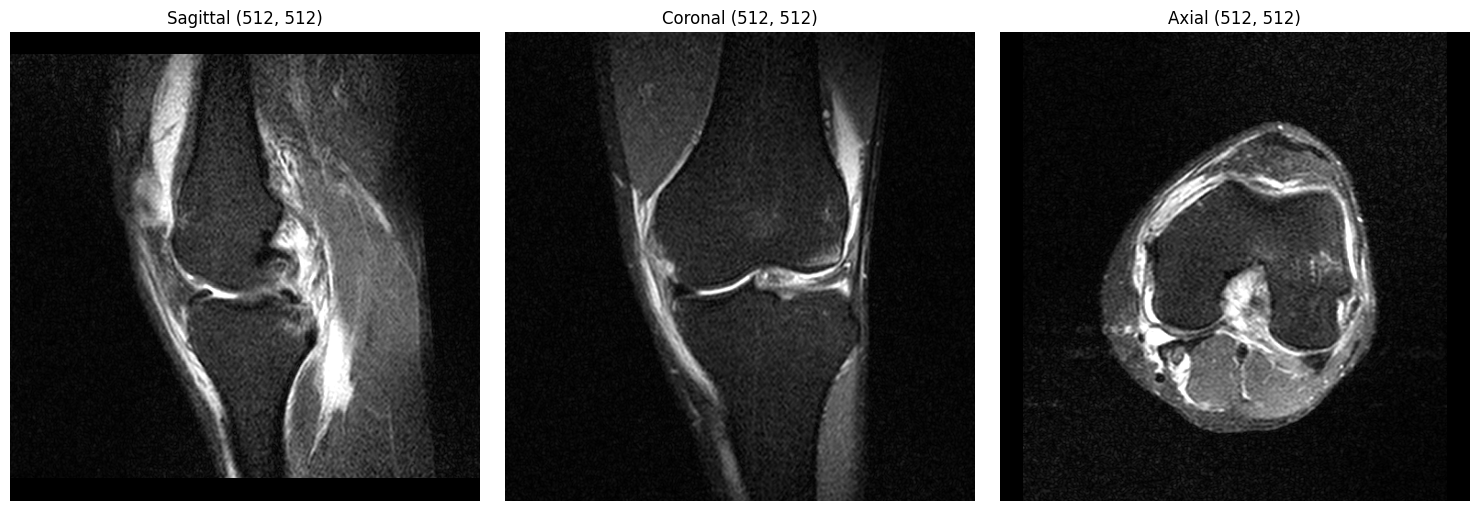

 Three planes generated and visualized successfully


In [17]:
if volume_normalized is not None and planes_volumes is not None:
 # Use the per-plane series extracted from the ZIP, not orthogonal slices from a mixed volume.
    axial_slices = [planes_volumes['axial'][idx] for idx in range(planes_volumes['axial'].shape[0])] if 'axial' in planes_volumes else []
    sagittal_slices = [planes_volumes['sagittal'][idx] for idx in range(planes_volumes['sagittal'].shape[0])] if 'sagittal' in planes_volumes else []
    coronal_slices = [planes_volumes['coronal'][idx] for idx in range(planes_volumes['coronal'].shape[0])] if 'coronal' in planes_volumes else []

    print(f" Axial slices: {len(axial_slices)} slices, each shape {axial_slices[0].shape if axial_slices else 'N/A'}")
    print(f" Sagittal slices: {len(sagittal_slices)} slices, each shape {sagittal_slices[0].shape if sagittal_slices else 'N/A'}")
    print(f" Coronal slices: {len(coronal_slices)} slices, each shape {coronal_slices[0].shape if coronal_slices else 'N/A'}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    mid_sagittal = sagittal_slices[len(sagittal_slices)//2] if sagittal_slices else None
    mid_coronal = coronal_slices[len(coronal_slices)//2] if coronal_slices else None
    mid_axial = axial_slices[len(axial_slices)//2] if axial_slices else None

    if mid_sagittal is not None:
        axes[0].imshow(mid_sagittal, cmap='gray')
    axes[0].set_title(f'Sagittal {mid_sagittal.shape if mid_sagittal is not None else "N/A"}')
    axes[0].axis('off')

    if mid_coronal is not None:
        axes[1].imshow(mid_coronal, cmap='gray')
    axes[1].set_title(f'Coronal {mid_coronal.shape if mid_coronal is not None else "N/A"}')
    axes[1].axis('off')

    if mid_axial is not None:
        axes[2].imshow(mid_axial, cmap='gray')
    axes[2].set_title(f'Axial {mid_axial.shape if mid_axial is not None else "N/A"}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(' Three planes generated and visualized successfully')
else:
    print('Cannot generate planes: volume not loaded')

In [18]:
if PATIENT_ZIP and Path(PATIENT_ZIP).exists():
    print(' Loading selectors from checkpoints...')

 # Create simple selector models that wrap the checkpoints
    class SelectorWrapper(nn.Module):
        def __init__(self, checkpoint_path, device='cpu'):
            super().__init__()
            self.device = device
            checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
            state_dict = checkpoint.get('model_state_dict', checkpoint)

 # Create compatible MobileNet model
            import timm
            self.model = timm.create_model('mobilenetv3_large_100', num_classes=2, pretrained=False)
            self.model.load_state_dict(state_dict, strict=False)
            self.model.to(device).eval()

        def forward(self, x):
            if x.shape[1] == 1:
                x = x.repeat(1, 3, 1, 1)
            return self.model(x)

        @torch.no_grad()
        def get_acl_probability(self, slice_2d):
            slice_tensor = torch.from_numpy(slice_2d).float()
            slice_tensor = slice_tensor.unsqueeze(0).unsqueeze(0)
            slice_tensor = slice_tensor.repeat(1, 3, 1, 1)
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
            slice_tensor = (slice_tensor - mean) / std
            slice_tensor = slice_tensor.to(self.device)
            logits = self.model(slice_tensor)
            probs = torch.softmax(logits, dim=1)
            return probs[0, 1].item()

        def select_top_k_slices(self, volume, k=5):
            acl_probs = [self.get_acl_probability(volume[i]) for i in range(volume.shape[0])]
            indices = np.argsort(acl_probs)[-k:]
            return sorted(indices.tolist())

 # Load selectors with their respective checkpoints
    selector_sagittal_path = CHECKPOINTS_DIR / 'acl_slice_classifier_v3' / 'best_model_f1.pth'
    selector_sagittal = SelectorWrapper(selector_sagittal_path, device=device)
    selector_sagittal.eval()

    selector_coronal_path = CHECKPOINTS_DIR / 'acl_slice_classifier_coronal' / 'best_model_f1.pth'
    selector_coronal = SelectorWrapper(selector_coronal_path, device=device)
    selector_coronal.eval()

    selector_axial_path = CHECKPOINTS_DIR / 'acl_slice_classifier_v3' / 'best_model_f1.pth'
    selector_axial = SelectorWrapper(selector_axial_path, device=device)
    selector_axial.eval()

    print(' All 3 selectors loaded successfully')
    print(f'  - Sagittal: acl_slice_classifier_v3')
    print(f'  - Coronal: acl_slice_classifier_coronal')
    print(f'  - Axial: acl_slice_classifier_v3')
else:
    print('Cannot load selectors: PATIENT_ZIP not set')

 Loading selectors from checkpoints...
 All 3 selectors loaded successfully
  - Sagittal: acl_slice_classifier_v3
  - Coronal: acl_slice_classifier_coronal
  - Axial: acl_slice_classifier_v3


In [19]:
K = 5  # Number of slices to select per plane

if volume_normalized is not None:
 # Create transform
    selector_transform = transforms.Compose([
        transforms.Resize((384, 384)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    selected_indices = {'sagittal': [], 'coronal': [], 'axial': []}
    acl_probabilities = {'sagittal': [], 'coronal': [], 'axial': []}

    def normalize_volume_for_selector(volume):
        volume = np.asarray(volume)
        return (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)

    def center_consecutive_indices(num_slices_total, k):
        start_idx = max(0, (num_slices_total - k) // 2)
        end_idx = start_idx + k
        indices = list(range(start_idx, min(end_idx, num_slices_total)))
        if len(indices) < k and indices:
            indices += [indices[-1]] * (k - len(indices))
        return indices

    def select_top_k_slices_from_selector(selector, volume, k=5):
        if hasattr(selector, 'select_top_k_slices'):
            return selector.select_top_k_slices(volume, k=k)
        if hasattr(selector, 'get_acl_probability'):
            acl_probs = [selector.get_acl_probability(volume[i]) for i in range(volume.shape[0])]
            indices = np.argsort(acl_probs)[-k:]
            return sorted(indices.tolist())
        raise RuntimeError('Selector does not provide slice selection or probability methods')

 # Process sagittal plane using CNN selector (same strategy as reference notebook)
    print(f'Processing sagittal plane ({len(sagittal_slices)} slices)...')
    sagittal_volume_norm = normalize_volume_for_selector(np.array(sagittal_slices))
    selected_indices['sagittal'] = select_top_k_slices_from_selector(selector_sagittal, sagittal_volume_norm, k=K)
    acl_probabilities['sagittal'] = [selector_sagittal.get_acl_probability(sagittal_volume_norm[idx]) for idx in selected_indices['sagittal']]
    print(f'   Sagittal: selected indices {selected_indices["sagittal"]} with probs {[f"{p:.3f}" for p in acl_probabilities["sagittal"]]}')

 # Process coronal plane using CNN selector (same strategy as reference notebook)
    print(f'Processing coronal plane ({len(coronal_slices)} slices)...')
    coronal_volume_norm = normalize_volume_for_selector(np.array(coronal_slices))
    selected_indices['coronal'] = select_top_k_slices_from_selector(selector_coronal, coronal_volume_norm, k=K)
    acl_probabilities['coronal'] = [selector_coronal.get_acl_probability(coronal_volume_norm[idx]) for idx in selected_indices['coronal']]
    print(f'   Coronal: selected indices {selected_indices["coronal"]} with probs {[f"{p:.3f}" for p in acl_probabilities["coronal"]]}')

 # Process axial plane using central slices (same strategy as reference notebook)
    print(f'Processing axial plane ({len(axial_slices)} slices)...')
    selected_indices['axial'] = center_consecutive_indices(len(axial_slices), K)
    acl_probabilities['axial'] = [None] * K
    print(f'   Axial: using central indices {selected_indices["axial"]}')
    print('\n Slice selection completed!')
else:
    print('Cannot select slices: volume not loaded')

Processing sagittal plane (38 slices)...
   Sagittal: selected indices [4, 7, 9, 12, 17] with probs ['0.501', '0.500', '0.501', '0.503', '0.501']
Processing coronal plane (36 slices)...
   Coronal: selected indices [20, 24, 25, 27, 34] with probs ['0.592', '0.591', '0.592', '0.590', '0.593']
Processing axial plane (40 slices)...
   Axial: using central indices [17, 18, 19, 20, 21]

 Slice selection completed!


INPUT TO SWIN: TOP 5 SLICES POR PLANO
Sagittal y coronal usan CNN selector; axial usa slices centrales.

Sagittal selected indices: [4, 7, 9, 12, 17]
Coronal selected indices:  [20, 24, 25, 27, 34]
Axial selected indices:     [17, 18, 19, 20, 21]

SAGITTAL:
  slice 1: idx=4, selector_prob=0.5006
  slice 2: idx=7, selector_prob=0.5002
  slice 3: idx=9, selector_prob=0.5008
  slice 4: idx=12, selector_prob=0.5031
  slice 5: idx=17, selector_prob=0.5005

CORONAL:
  slice 1: idx=20, selector_prob=0.5923
  slice 2: idx=24, selector_prob=0.5909
  slice 3: idx=25, selector_prob=0.5918
  slice 4: idx=27, selector_prob=0.5902
  slice 5: idx=34, selector_prob=0.5927

AXIAL:
  slice 1: idx=17, central_slice=True
  slice 2: idx=18, central_slice=True
  slice 3: idx=19, central_slice=True
  slice 4: idx=20, central_slice=True
  slice 5: idx=21, central_slice=True


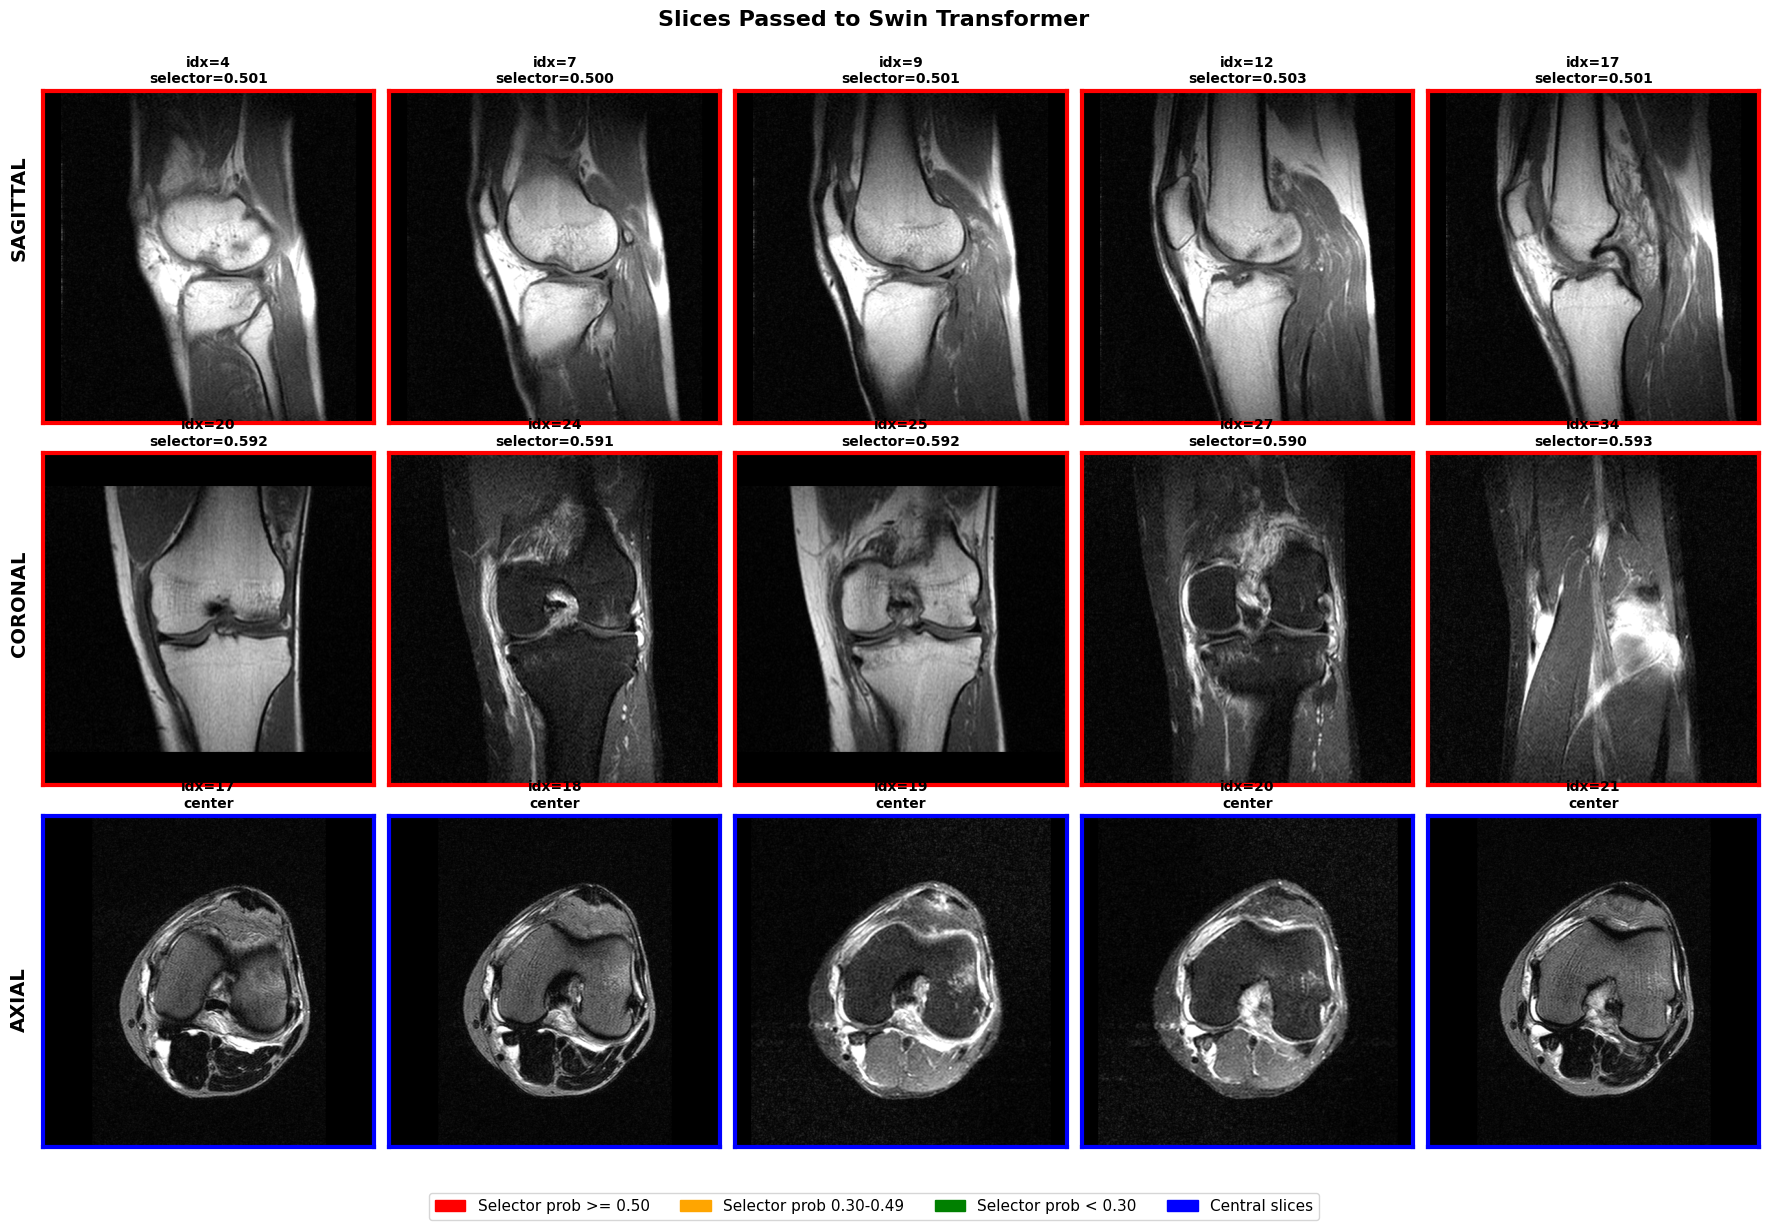


 Input-to-Swin visualization completed


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if volume_normalized is not None and selected_indices['sagittal']:
    print('='*80)
    print('INPUT TO SWIN: TOP 5 SLICES POR PLANO')
    print('='*80)
    print('Sagittal y coronal usan CNN selector; axial usa slices centrales.')
    print('')
    print(f'Sagittal selected indices: {selected_indices["sagittal"]}')
    print(f'Coronal selected indices:  {selected_indices["coronal"]}')
    print(f'Axial selected indices:     {selected_indices["axial"]}')

    fig, axes = plt.subplots(3, K, figsize=(18, 12))

    plane_specs = [
        ('SAGITTAL', sagittal_slices, selected_indices['sagittal'], acl_probabilities['sagittal'], 0, 'selector'),
        ('CORONAL', coronal_slices, selected_indices['coronal'], acl_probabilities['coronal'], 1, 'selector'),
        ('AXIAL', axial_slices, selected_indices['axial'], acl_probabilities['axial'], 2, 'central'),
    ]

    for plane_name, slices_stack, selected_idx_list, selected_probs, row, strategy in plane_specs:
        print(f'\n{plane_name}:')
        for col, slice_idx in enumerate(selected_idx_list):
            slice_img = slices_stack[slice_idx]
            prob = selected_probs[col] if selected_probs and selected_probs[col] is not None else None

            if strategy == 'central':
                print(f'  slice {col + 1}: idx={slice_idx}, central_slice=True')
            else:
                print(f'  slice {col + 1}: idx={slice_idx}, selector_prob={prob:.4f}')

            ax = axes[row, col]
            ax.imshow(slice_img, cmap='gray')
            if strategy == 'central':
                ax.set_title(f'idx={slice_idx}\ncenter', fontsize=10, fontweight='bold')
            else:
                ax.set_title(f'idx={slice_idx}\nselector={prob:.3f}', fontsize=10, fontweight='bold')

            if strategy == 'central':
                color = 'blue'
            else:
                if prob >= 0.5:
                    color = 'red'
                elif prob >= 0.3:
                    color = 'orange'
                else:
                    color = 'green'

            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

            ax.set_xticks([])
            ax.set_yticks([])

        fig.text(0.02, 0.83 - row * 0.33, plane_name, fontsize=14, fontweight='bold', rotation=90, va='center')

    red_patch = mpatches.Patch(color='red', label='Selector prob >= 0.50')
    orange_patch = mpatches.Patch(color='orange', label='Selector prob 0.30-0.49')
    green_patch = mpatches.Patch(color='green', label='Selector prob < 0.30')
    blue_patch = mpatches.Patch(color='blue', label='Central slices')
    fig.legend(handles=[red_patch, orange_patch, green_patch, blue_patch], loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=11)
    plt.suptitle('Slices Passed to Swin Transformer', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.99])
    plt.show()

    print('\n' + '='*80)
    print(' Input-to-Swin visualization completed')
    print('='*80)
else:
    print(' No se pueden visualizar: volumen no cargado o slices no seleccionadas')

In [21]:
if PATIENT_ZIP and Path(PATIENT_ZIP).exists():
    print(' Loading selectors from checkpoints...')

    class SimpleCNNSelector(nn.Module):
        """CNN selector based on MobileNetV2, matching the reference notebook."""
        def __init__(self, checkpoint_path, device='cpu'):
            super().__init__()
            import timm

            checkpoint = torch.load(checkpoint_path, map_location='cpu')
            state_dict = checkpoint.get('model_state_dict', checkpoint)
            new_state_dict = {}
            for key, value in state_dict.items():
                clean_key = key.replace('module.', '') if key.startswith('module.') else key
                new_state_dict[clean_key] = value

            self.device = device
            self.backbone = timm.create_model('mobilenetv2_100', pretrained=False, num_classes=0)

            if 'backbone.classifier.1.weight' in new_state_dict:
                self.backbone.classifier = nn.Sequential(
                    nn.Dropout(0.2),
                    nn.Linear(1280, 2),
                )
                self.model = self.backbone
            else:
                self.classifier = nn.Sequential(
                    nn.Dropout(0.3),
                    nn.Linear(1280, 128),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(128, 2),
                )
                self.model = nn.Sequential(self.backbone, self.classifier)

            self.load_state_dict(new_state_dict, strict=False)
            self.to(device)

        def forward(self, x):
            if x.shape[1] == 1:
                x = x.repeat(1, 3, 1, 1)
            if hasattr(self, 'classifier') and self.classifier is not None:
                features = self.backbone(x)
                return self.classifier(features)
            return self.backbone(x)

        def get_acl_probability(self, slice_2d):
            """Return ACL probability for a single 2D slice."""
            slice_tensor = torch.from_numpy(slice_2d).float()
            slice_tensor = slice_tensor.unsqueeze(0).unsqueeze(0)
            slice_tensor = slice_tensor.repeat(1, 3, 1, 1)

            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
            slice_tensor = (slice_tensor - mean) / std
            slice_tensor = slice_tensor.to(self.device)

            with torch.no_grad():
                logits = self.forward(slice_tensor)
                probs = torch.softmax(logits, dim=1)
                return probs[0, 1].item()

        def select_top_k_slices(self, volume, k=5):
            """Select the k slices with highest ACL probability."""
            acl_probs = []
            for i in range(volume.shape[0]):
                prob = self.get_acl_probability(volume[i])
                acl_probs.append(prob)
            indices = np.argsort(acl_probs)[-k:]
            indices = sorted(indices.tolist())
            return indices

    SelectorWrapper = SimpleCNNSelector

    selector_sagittal_path = CHECKPOINTS_DIR / 'acl_slice_classifier_v3' / 'best_model_f1.pth'
    selector_sagittal = SelectorWrapper(selector_sagittal_path, device=device)
    selector_sagittal.eval()

    selector_coronal_path = CHECKPOINTS_DIR / 'acl_slice_classifier_coronal' / 'best_model_f1.pth'
    selector_coronal = SelectorWrapper(selector_coronal_path, device=device)
    selector_coronal.eval()

    selector_axial_path = CHECKPOINTS_DIR / 'acl_slice_classifier_v3' / 'best_model_f1.pth'
    selector_axial = SelectorWrapper(selector_axial_path, device=device)
    selector_axial.eval()

    print(' All 3 selectors loaded successfully')
    print(f'  - Sagittal: acl_slice_classifier_v3')
    print(f'  - Coronal: acl_slice_classifier_coronal')
    print(f'  - Axial: acl_slice_classifier_v3')
else:
    print('Cannot load selectors: PATIENT_ZIP not set')

 Loading selectors from checkpoints...
 All 3 selectors loaded successfully
  - Sagittal: acl_slice_classifier_v3
  - Coronal: acl_slice_classifier_coronal
  - Axial: acl_slice_classifier_v3


In [22]:
from src.data_loader import OptimizedMRNetDataset

if volume_normalized is not None and selected_indices['sagittal']:
    print(' Creating dataset for all 3 planes...')

 # Model input transform
    model_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])

    class MultiSliceDataset:
        def __init__(self, slices_list, selected_indices, transform=None):
            self.slices = [slices_list[i % len(slices_list)] for i in selected_indices]
            self.transform = transform

        def __len__(self):
            return 1

        def __getitem__(self, idx):
            all_slices = []
            for slice_2d in self.slices:
                img = Image.fromarray(slice_2d.astype(np.uint8)).convert('RGB')
                if self.transform:
                    img = self.transform(img)
                all_slices.append(img)
            return torch.stack(all_slices, dim=0)

 # Create datasets for each plane
    dataset_sagittal = MultiSliceDataset(sagittal_slices, selected_indices['sagittal'], model_transform)
    dataset_coronal = MultiSliceDataset(coronal_slices, selected_indices['coronal'], model_transform)
    dataset_axial = MultiSliceDataset(axial_slices, selected_indices['axial'], model_transform)

    print(f' Datasets created:')
    print(f'  - Sagittal: {len(selected_indices["sagittal"])} selected slices')
    print(f'  - Coronal: {len(selected_indices["coronal"])} selected slices')
    print(f'  - Axial: {len(selected_indices["axial"])} selected slices')
else:
    print('Cannot create datasets: volume not loaded or slices not selected')

 Creating dataset for all 3 planes...
 Datasets created:
  - Sagittal: 5 selected slices
  - Coronal: 5 selected slices
  - Axial: 5 selected slices


In [23]:
from src.models import SwinMultiSliceClassifier

SWIN_SMALL_MULTISEED_DIR = CHECKPOINTS_DIR / 'swin_small_multiseed'
SWIN_SMALL_MODELS = {
    'sagittal': SWIN_SMALL_MULTISEED_DIR / 'best_sagittal_multiseed_final.pth',
    'coronal': SWIN_SMALL_MULTISEED_DIR / 'best_coronal_multiseed_final.pth',
    'axial': SWIN_SMALL_MULTISEED_DIR / 'best_axial_multiseed_final.pth',
}

def load_swin_model(model_path, device):
    model = SwinMultiSliceClassifier()
    checkpoint = torch.load(str(model_path), map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    else:
        model.load_state_dict(checkpoint, strict=False)
    return model.to(device).eval()

print(' Loading Swin models...')
swin_sagittal = load_swin_model(SWIN_SMALL_MODELS['sagittal'], device)
swin_coronal = load_swin_model(SWIN_SMALL_MODELS['coronal'], device)
swin_axial = load_swin_model(SWIN_SMALL_MODELS['axial'], device)
swin_models = {
    'sagittal': swin_sagittal,
    'coronal': swin_coronal,
    'axial': swin_axial,
}
print(' Swin models loaded successfully')
print(f'  - Sagittal: {SWIN_SMALL_MODELS["sagittal"].name}')
print(f'  - Coronal: {SWIN_SMALL_MODELS["coronal"].name}')
print(f'  - Axial: {SWIN_SMALL_MODELS["axial"].name}')

 Loading Swin models...


 Swin models loaded successfully
  - Sagittal: best_sagittal_multiseed_final.pth
  - Coronal: best_coronal_multiseed_final.pth
  - Axial: best_axial_multiseed_final.pth


In [24]:
def get_predictions_on_dataset(model, dataset, batch_size=1, device='cpu'):
    """Get predictions on dataset

    Args:
        model: PyTorch model in eval mode (expects input (B, K, 3, H, W))
        dataset: Dataset object that returns (K, 3, 224, 224) tensors
        batch_size: Batch size for inference
        device: Device to run on

    Returns:
        predictions: numpy array of ACL probabilities
    """
    from torch.utils.data import DataLoader

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_predictions = []

    with torch.no_grad():
        for batch in dataloader:  # batch shape: (1, K, 3, 224, 224) or (B, K, 3, 224, 224)
            batch = batch.to(device)
            output = model(batch)  # May return tuple (logits, attention_weights)

 # Extract logits if tuple
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

 # Handle different output formats
            if logits.shape[-1] == 1:
 # Binary output from model
                probs = torch.sigmoid(logits).squeeze()
            else:
 # Multi-class output
                probs = torch.nn.functional.softmax(logits, dim=1)
                if probs.shape[-1] >= 2:
                    probs = probs[:, 1]  # ACL class probability

 # Convert to numpy - handle both single value and array
            if isinstance(probs, torch.Tensor):
                if probs.dim() == 0:
                    acl_probs = probs.cpu().numpy()
                else:
                    acl_probs = probs.cpu().numpy()
            else:
                acl_probs = np.array(probs)

            all_predictions.append(acl_probs)

    result = np.array(all_predictions).flatten()
    return result if result.size > 0 else np.array([0.5])

print(' get_predictions_on_dataset function defined')

 get_predictions_on_dataset function defined


In [25]:
if volume_normalized is not None and selected_indices['sagittal']:
    print('\n=== GETTING PREDICTIONS ===')
 # Get predictions from each plane
    print('Getting predictions from sagittal plane...')
    predictions_sagittal = get_predictions_on_dataset(swin_sagittal, dataset_sagittal, device=device)

    print('Getting predictions from coronal plane...')
    predictions_coronal = get_predictions_on_dataset(swin_coronal, dataset_coronal, device=device)

    print('Getting predictions from axial plane...')
    predictions_axial = get_predictions_on_dataset(swin_axial, dataset_axial, device=device)

    print(f'\nPredictions obtained:')
    print(f'  Sagittal: shape={predictions_sagittal.shape}, mean={predictions_sagittal.mean():.4f}, values={predictions_sagittal}')
    print(f'  Coronal: shape={predictions_coronal.shape}, mean={predictions_coronal.mean():.4f}, values={predictions_coronal}')
    print(f'  Axial: shape={predictions_axial.shape}, mean={predictions_axial.mean():.4f}, values={predictions_axial}')
else:
    print('Cannot get predictions: volume not loaded')


=== GETTING PREDICTIONS ===
Getting predictions from sagittal plane...
Getting predictions from coronal plane...
Getting predictions from axial plane...

Predictions obtained:
  Sagittal: shape=(1,), mean=0.2886, values=[0.28855664]
  Coronal: shape=(1,), mean=0.9490, values=[0.94901776]
  Axial: shape=(1,), mean=0.9148, values=[0.914839]


In [26]:
if volume_normalized is not None and selected_indices['sagittal']:
 # Ensemble: average predictions from all planes
 # Take mean across all selected slices from each plane, then ensemble
    ensemble_prob_sagittal = predictions_sagittal.mean()
    ensemble_prob_coronal = predictions_coronal.mean()
    ensemble_prob_axial = predictions_axial.mean()

 # Final ensemble: average across planes
    final_ensemble_prob = (ensemble_prob_sagittal + ensemble_prob_coronal + ensemble_prob_axial) / 3.0

 # Threshold calibrated in Threshold_Tuning_and_External_Validation.ipynb
    THRESHOLD = 0.3734
    acl_injury_predicted = final_ensemble_prob >= THRESHOLD

    print(f'\n=== ENSEMBLE PROBABILITIES ===')
    print(f'Sagittal mean: {ensemble_prob_sagittal:.4f}')
    print(f'Coronal mean: {ensemble_prob_coronal:.4f}')
    print(f'Axial mean: {ensemble_prob_axial:.4f}')
    print(f'\nFinal ensemble (average): {final_ensemble_prob:.4f}')
    print(f'Threshold: {THRESHOLD}')
    print(f'ACL Injury Predicted: {acl_injury_predicted}')
else:
    print('Cannot perform ensemble: predictions not computed')


=== ENSEMBLE PROBABILITIES ===
Sagittal mean: 0.2886
Coronal mean: 0.9490
Axial mean: 0.9148

Final ensemble (average): 0.7175
Threshold: 0.3734
ACL Injury Predicted: True



ATTENTION VISUALIZATION FOR THE ENSEMBLE
These are the 5 slices selected by the selector for each plane, sorted by Swin attention weight.

SAGITTAL:
  rank 1: selected_idx=4, selector_pos=0, attention=0.2802
  rank 2: selected_idx=7, selector_pos=1, attention=0.2271
  rank 3: selected_idx=12, selector_pos=3, attention=0.2198
  rank 4: selected_idx=9, selector_pos=2, attention=0.1682
  rank 5: selected_idx=17, selector_pos=4, attention=0.1046
CORONAL:
  rank 1: selected_idx=25, selector_pos=2, attention=0.9964
  rank 2: selected_idx=20, selector_pos=0, attention=0.0030
  rank 3: selected_idx=24, selector_pos=1, attention=0.0002
  rank 4: selected_idx=34, selector_pos=4, attention=0.0002
  rank 5: selected_idx=27, selector_pos=3, attention=0.0001
AXIAL:
  rank 1: selected_idx=20, selector_pos=3, attention=0.4842
  rank 2: selected_idx=19, selector_pos=2, attention=0.4178
  rank 3: selected_idx=17, selector_pos=0, attention=0.0527
  rank 4: selected_idx=21, selector_pos=4, attention=0.02

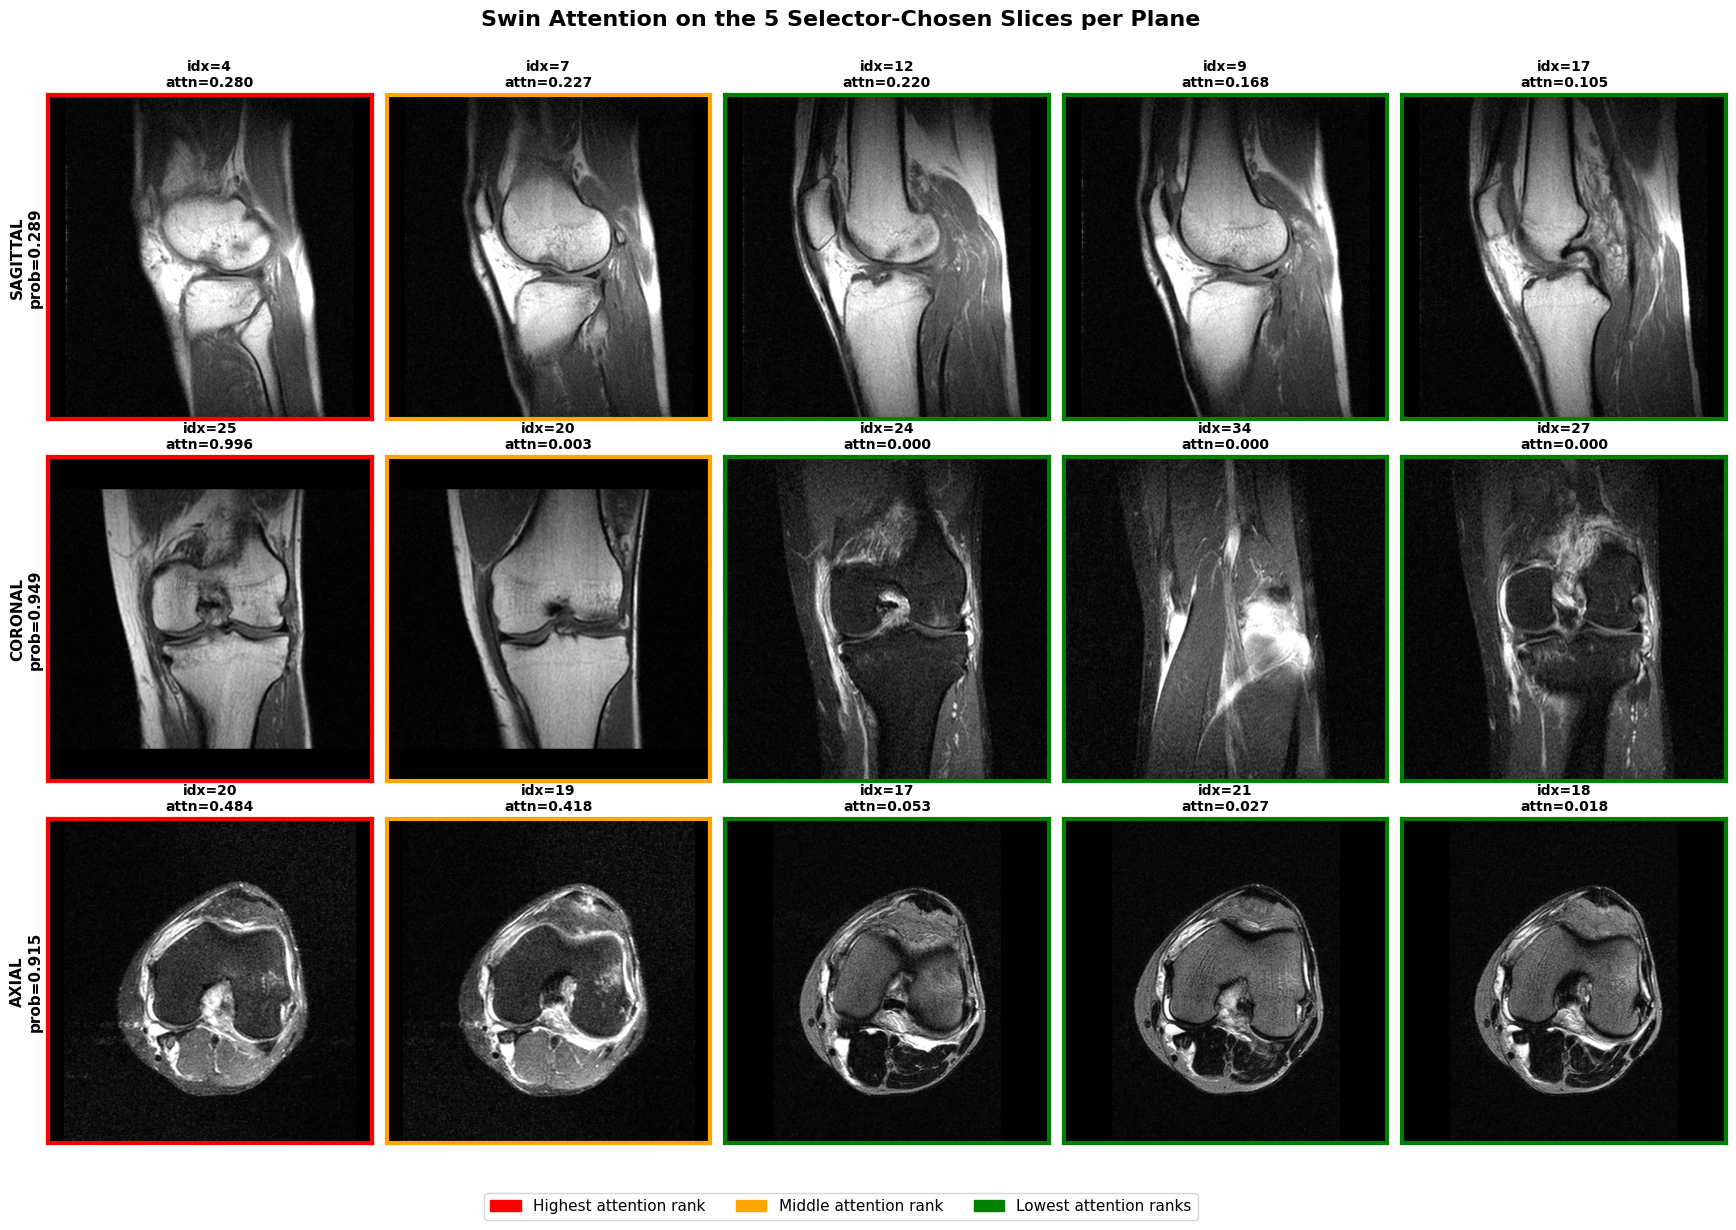


 Attention visualization completed


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader

if volume_normalized is not None and selected_indices['sagittal']:
    print('\n' + '='*80)
    print('ATTENTION VISUALIZATION FOR THE ENSEMBLE')
    print('='*80)
    print('These are the 5 slices selected by the selector for each plane, sorted by Swin attention weight.')
    print('')

    def get_attention_weights(model, dataset, device='cpu'):
        dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
        batch = next(iter(dataloader)).to(device)
        with torch.no_grad():
            output = model(batch)
        if isinstance(output, tuple):
            logits, attention_weights = output
        else:
            logits = output
            attention_weights = None
        if attention_weights is None:
            raise ValueError('This model did not return attention weights. Ensure pooling_mode="attention".')
        return attention_weights.squeeze(0).detach().cpu().numpy(), logits.squeeze(0).detach().cpu().numpy()

    plane_payloads = [
        ('SAGITTAL', sagittal_slices, selected_indices['sagittal'], dataset_sagittal, swin_sagittal, predictions_sagittal),
        ('CORONAL', coronal_slices, selected_indices['coronal'], dataset_coronal, swin_coronal, predictions_coronal),
        ('AXIAL', axial_slices, selected_indices['axial'], dataset_axial, swin_axial, predictions_axial),
    ]

    fig, axes = plt.subplots(3, K, figsize=(18, 12))
    if K == 1:
        axes = np.array([[axes[0]], [axes[1]], [axes[2]]])

    for row, (plane_name, slices_stack, selected_idx_list, dataset, model, plane_predictions) in enumerate(plane_payloads):
        attention_weights, logits = get_attention_weights(model, dataset, device=device)
        order = np.argsort(attention_weights)[::-1]
        sorted_indices = [selected_idx_list[i] for i in order]
        sorted_weights = attention_weights[order]

        print(f'{plane_name}:')
        for rank, (slice_pos, slice_idx, weight) in enumerate(zip(order, sorted_indices, sorted_weights), start=1):
            print(f'  rank {rank}: selected_idx={slice_idx}, selector_pos={slice_pos}, attention={weight:.4f}')

        for col, slice_pos in enumerate(order[:K]):
            slice_idx = selected_idx_list[slice_pos]
            slice_img = slices_stack[slice_idx]
            weight = attention_weights[slice_pos]

            ax = axes[row, col]
            ax.imshow(slice_img, cmap='gray')
            ax.set_title(f'idx={slice_idx}\nattn={weight:.3f}', fontsize=10, fontweight='bold')

            if col == 0:
                ax.set_ylabel(f'{plane_name}\nprob={float(np.mean(plane_predictions)):.3f}', fontsize=11, fontweight='bold')

            if col == 0:
                border_color = 'red'
            elif col == 1:
                border_color = 'orange'
            else:
                border_color = 'green'
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)

            ax.set_xticks([])
            ax.set_yticks([])

    red_patch = mpatches.Patch(color='red', label='Highest attention rank')
    orange_patch = mpatches.Patch(color='orange', label='Middle attention rank')
    green_patch = mpatches.Patch(color='green', label='Lowest attention ranks')
    fig.legend(handles=[red_patch, orange_patch, green_patch], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=11)
    plt.suptitle('Swin Attention on the 5 Selector-Chosen Slices per Plane', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.99])
    plt.show()

    print('\n' + '='*80)
    print(' Attention visualization completed')
    print('='*80)
else:
    print(' Cannot visualize attention: volume not loaded or slices not selected')


SALIENCY OVERLAYS FOR THE ENSEMBLE
Mapa de saliency para las 5 slices con mayor atención en cada plano.

SAGITTAL:
  rank 1: selected_idx=4, selector_pos=0, attention=0.2802
  rank 2: selected_idx=7, selector_pos=1, attention=0.2271
  rank 3: selected_idx=12, selector_pos=3, attention=0.2198
  rank 4: selected_idx=9, selector_pos=2, attention=0.1682
  rank 5: selected_idx=17, selector_pos=4, attention=0.1046
CORONAL:
  rank 1: selected_idx=25, selector_pos=2, attention=0.9964
  rank 2: selected_idx=20, selector_pos=0, attention=0.0030
  rank 3: selected_idx=24, selector_pos=1, attention=0.0002
  rank 4: selected_idx=34, selector_pos=4, attention=0.0002
  rank 5: selected_idx=27, selector_pos=3, attention=0.0001
AXIAL:
  rank 1: selected_idx=20, selector_pos=3, attention=0.4842
  rank 2: selected_idx=19, selector_pos=2, attention=0.4178
  rank 3: selected_idx=17, selector_pos=0, attention=0.0527
  rank 4: selected_idx=21, selector_pos=4, attention=0.0272
  rank 5: selected_idx=18, sele

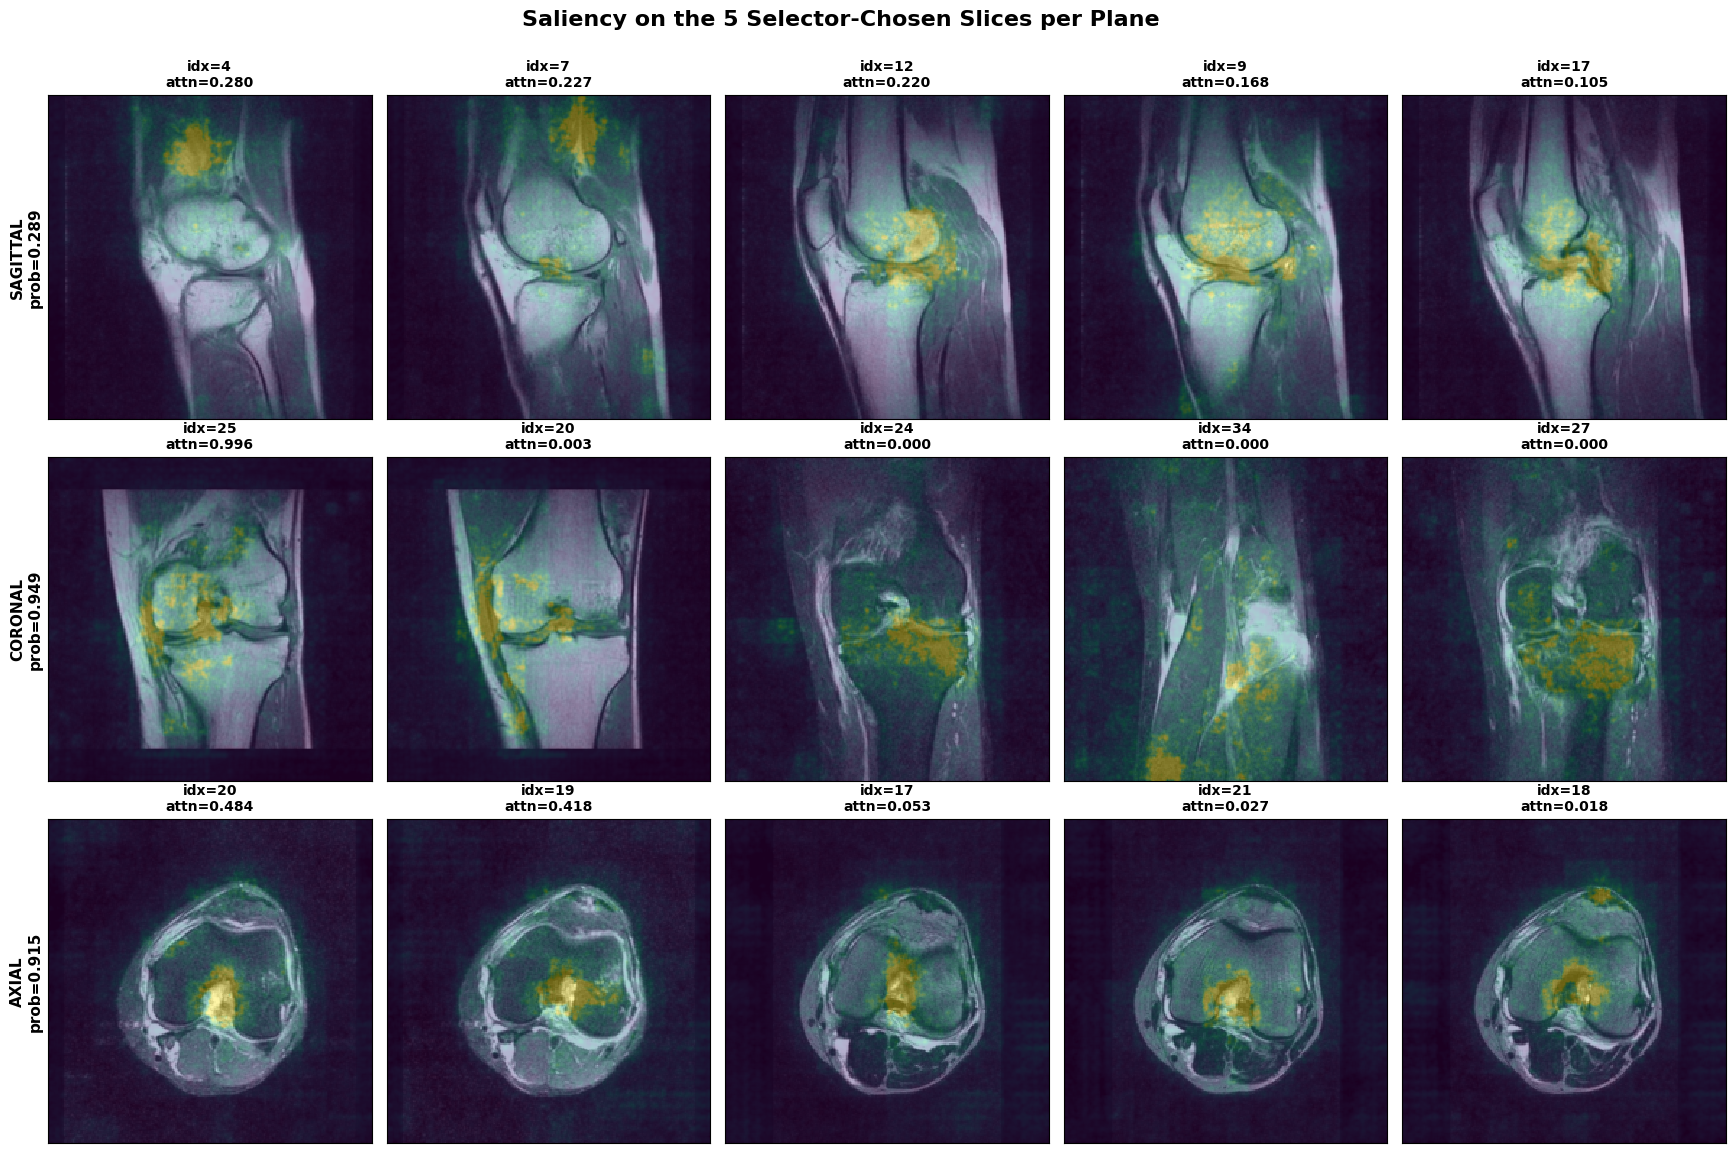


 Saliency overlays completed


In [28]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image

if volume_normalized is not None and selected_indices['sagittal']:
    print('\n' + '='*80)
    print('SALIENCY OVERLAYS FOR THE ENSEMBLE')
    print('='*80)
    print('Mapa de saliency para las 5 slices con mayor atención en cada plano.')
    print('')

    def slice_to_rgb_tensor(slice_2d):
        img = Image.fromarray(slice_2d.astype(np.uint8)).convert('RGB')
        return model_transform(img)

    def robust_unit_scale(arr, low_q=2, high_q=98):
        low = np.percentile(arr, low_q)
        high = np.percentile(arr, high_q)
        if high - low < 1e-8:
            return np.zeros_like(arr)
        return np.clip((arr - low) / (high - low), 0, 1)

    def input_saliency_for_slice(model, slice_rgb, device):
        model.eval()
        x = slice_rgb.unsqueeze(0).to(device)
        x.requires_grad_(True)

        model.backbone.zero_grad(set_to_none=True)
        model.zero_grad(set_to_none=True)

        feat_map = model.backbone.forward_features(x)
        feat_vec = model.backbone.forward_head(feat_map, pre_logits=True)
        pooled_features, _ = model.pooling(feat_vec.unsqueeze(1))
        logits = model.classifier(pooled_features)

        score = logits.squeeze()
        score.backward()

        saliency = x.grad.detach().abs().mean(dim=1, keepdim=True)
        saliency = F.avg_pool2d(saliency, kernel_size=3, stride=1, padding=1)
        saliency = F.interpolate(saliency, size=slice_rgb.shape[-2:], mode='bilinear', align_corners=False)
        saliency = saliency[0, 0].cpu().numpy()
        saliency = robust_unit_scale(saliency, low_q=1, high_q=99)
        saliency = np.power(saliency, 0.55)

        pred_prob = float(torch.sigmoid(score).detach().cpu().item())
        return saliency, pred_prob

    def plot_case_saliency_maps(case_results, out_path=None, top_n=None, title=None, heat_alpha=0.35, heat_cmap='viridis'):
        planes = list(case_results.keys())
        n_planes = len(planes)
        max_k = top_n if top_n is not None else max(len(case_results[p]['attn']) for p in planes)

        fig, axes = plt.subplots(n_planes, max_k, figsize=(4 * max_k, 4 * n_planes), squeeze=False)

        for row, plane in enumerate(planes):
            data = case_results[plane]
            attn = data['attn']
            order = np.argsort(attn)[::-1]
            if top_n is not None:
                order = order[:top_n]

            for col in range(max_k):
                ax = axes[row, col]
                if col >= len(order):
                    ax.axis('off')
                    continue

                idx = order[col]
                slice_rgb = data['slices_rgb'][idx].detach().cpu().numpy()
                saliency = data['saliency'][idx]

                gray = slice_rgb.mean(axis=0)
                gray = gray - gray.min()
                gray = gray / (gray.max() + 1e-8)

                ax.imshow(gray, cmap='gray', interpolation='nearest')
                ax.imshow(saliency, cmap=heat_cmap, alpha=heat_alpha, vmin=0, vmax=1, interpolation='bilinear')
                ax.set_title(f'{plane} | slice {idx}\nattn={attn[idx]:.3f}', fontsize=9)
                ax.axis('off')

        if title:
            fig.suptitle(title, y=1.01, fontsize=14)

        plt.tight_layout()
        if out_path is not None:
            fig.savefig(out_path, bbox_inches='tight', dpi=150)
        plt.show()

    plane_payloads = [
        ('SAGITTAL', sagittal_slices, selected_indices['sagittal'], dataset_sagittal, swin_sagittal, predictions_sagittal),
        ('CORONAL', coronal_slices, selected_indices['coronal'], dataset_coronal, swin_coronal, predictions_coronal),
        ('AXIAL', axial_slices, selected_indices['axial'], dataset_axial, swin_axial, predictions_axial),
    ]

    case_results = {}
    for plane_name, slices_stack, selected_idx_list, dataset, model, plane_predictions in plane_payloads:
        attention_weights, _ = get_attention_weights(model, dataset, device=device)
        order = np.argsort(attention_weights)[::-1][:K]
        saliency_maps = {}
        slices_rgb = []
        for idx in selected_idx_list:
            slices_rgb.append(slice_to_rgb_tensor(slices_stack[idx]))
        slices_rgb = torch.stack(slices_rgb, dim=0)
        for pos in order:
            saliency, _ = input_saliency_for_slice(model, slices_rgb[pos], device)
            saliency_maps[pos] = saliency
        case_results[plane_name] = {
            'slices_rgb': slices_rgb,
            'attn': attention_weights,
            'saliency': saliency_maps,
        }

    fig, axes = plt.subplots(3, K, figsize=(18, 12))
    if K == 1:
        axes = np.array([[axes[0]], [axes[1]], [axes[2]]])

    for row, (plane_name, slices_stack, selected_idx_list, dataset, model, plane_predictions) in enumerate(plane_payloads):
        attention_weights, _ = get_attention_weights(model, dataset, device=device)
        order = np.argsort(attention_weights)[::-1]
        sorted_indices = [selected_idx_list[i] for i in order]
        sorted_weights = attention_weights[order]

        print(f'{plane_name}:')
        for rank, (slice_pos, slice_idx, weight) in enumerate(zip(order, sorted_indices, sorted_weights), start=1):
            print(f'  rank {rank}: selected_idx={slice_idx}, selector_pos={slice_pos}, attention={weight:.4f}')

        for col, slice_pos in enumerate(order[:K]):
            slice_idx = selected_idx_list[slice_pos]
            slice_rgb = case_results[plane_name]['slices_rgb'][slice_pos].detach().cpu().numpy()
            saliency = case_results[plane_name]['saliency'][slice_pos]

            gray = slice_rgb.mean(axis=0)
            gray = gray - gray.min()
            gray = gray / (gray.max() + 1e-8)

            ax = axes[row, col]
            ax.imshow(gray, cmap='gray', interpolation='nearest')
            ax.imshow(saliency, cmap='viridis', alpha=0.40, vmin=0, vmax=1, interpolation='bilinear')
            ax.set_title(f'idx={slice_idx}\nattn={attention_weights[slice_pos]:.3f}', fontsize=10, fontweight='bold')

            if col == 0:
                ax.set_ylabel(f'{plane_name}\nprob={float(np.mean(plane_predictions)):.3f}', fontsize=11, fontweight='bold')

            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle('Saliency on the 5 Selector-Chosen Slices per Plane', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.99])
    plt.show()

    print('\n' + '='*80)
    print(' Saliency overlays completed')
    print('='*80)
else:
    print(' Cannot visualize saliency: volume not loaded or slices not selected')


SALIENCY CLOSE-UP: SAGITTAL SLICES 11 AND 17
Vista rápida de saliency para las slices sagittal que antes quedaban sin señal en Grad-CAM.
SAGITTAL slice 17: saliency max=1.0000, mean=0.3758


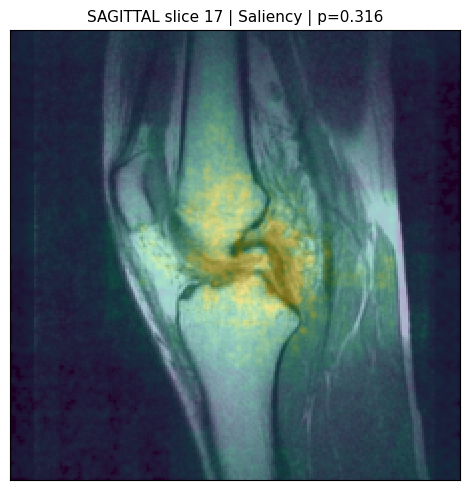


 Saliency close-up completed


In [29]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

if volume_normalized is not None and selected_indices['sagittal']:
    print('\n' + '='*80)
    print('SALIENCY CLOSE-UP: SAGITTAL SLICES 11 AND 17')
    print('='*80)
    print('Vista rápida de saliency para las slices sagittal que antes quedaban sin señal en Grad-CAM.')

    def robust_unit_scale(arr, low_q=2, high_q=98):
        low = np.percentile(arr, low_q)
        high = np.percentile(arr, high_q)
        if high - low < 1e-8:
            return np.zeros_like(arr)
        return np.clip((arr - low) / (high - low), 0, 1)

    target_sagittal_indices = [idx for idx in [11, 17] if idx in selected_indices['sagittal']]
    if not target_sagittal_indices:
        target_sagittal_indices = selected_indices['sagittal'][:2]

    fig, axes = plt.subplots(1, len(target_sagittal_indices), figsize=(5 * len(target_sagittal_indices), 5))
    if len(target_sagittal_indices) == 1:
        axes = np.array([axes])

    for ax, slice_idx in zip(axes, target_sagittal_indices):
        slice_rgb = slice_to_rgb_tensor(sagittal_slices[slice_idx])
        saliency, sal_prob = input_saliency_for_slice(swin_sagittal, slice_rgb, device)

        base_gray = slice_rgb.detach().cpu().numpy().mean(axis=0)
        base_gray = robust_unit_scale(base_gray, low_q=1, high_q=99)
        saliency_vis = robust_unit_scale(saliency, low_q=1, high_q=99)
        saliency_vis = np.power(saliency_vis, 0.55)

        ax.imshow(base_gray, cmap='gray', interpolation='nearest')
        ax.imshow(saliency_vis, cmap='viridis', alpha=0.42, vmin=0, vmax=1, interpolation='bilinear')
        ax.set_title(f'SAGITTAL slice {slice_idx} | Saliency | p={sal_prob:.3f}', fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])
        print(f'SAGITTAL slice {slice_idx}: saliency max={saliency_vis.max():.4f}, mean={saliency_vis.mean():.4f}')

    plt.tight_layout()
    plt.show()

    print('\n' + '='*80)
    print(' Saliency close-up completed')
    print('='*80)
else:
    print('No hay slices sagitales seleccionadas para visualizar.')

In [30]:
if volume_normalized is not None and selected_indices['sagittal']:
 # Final diagnosis results
    print('\n' + '='*70)
    print('FINAL ACL INJURY CLASSIFICATION RESULTS')
    print('='*70)

    diagnosis_class = 'ACL INJURY' if acl_injury_predicted else 'NO ACL INJURY'

    def threshold_normalized_score(prob, threshold):
        if threshold <= 0.0 or threshold >= 1.0:
            return prob
        if prob >= threshold:
            return 0.5 + 0.5 * (prob - threshold) / (1.0 - threshold + 1e-8)
        return 0.5 * prob / (threshold + 1e-8)

    calibrated_confidence = threshold_normalized_score(final_ensemble_prob, THRESHOLD)
    confidence_label = 'strong' if calibrated_confidence >= 0.75 else 'moderate' if calibrated_confidence >= 0.60 else 'weak'

    print(f'\nDIAGNOSIS: {diagnosis_class}')
    print(f'Calibrated confidence: {calibrated_confidence:.4f} ({calibrated_confidence*100:.2f}%)')
    print(f'Raw ensemble probability: {final_ensemble_prob:.4f} ({final_ensemble_prob*100:.2f}%)')
    print(f'Interpretation: {diagnosis_class} with {confidence_label} confidence relative to threshold {THRESHOLD:.4f}')
    print(f'\nPer-Plane Breakdown:')
    print(f'  - Sagittal plane: {ensemble_prob_sagittal:.4f}')
    print(f'  - Coronal plane: {ensemble_prob_coronal:.4f}')
    print(f'  - Axial plane: {ensemble_prob_axial:.4f}')
    print(f'\nModel Details:')
    print(f'  - Slice Selectors: SimpleCNNSelector')
    print(f'    * Sagittal: acl_slice_classifier_v3')
    print(f'    * Coronal: acl_slice_classifier_coronal')
    print(f'    * Axial: acl_slice_classifier_v3')
    print(f'  - Classification Models: Swin Small Transformer (multiseed)')
    print(f'  - Ensemble method: Averaging across {K} selected slices per plane, then averaging across planes')
    print(f'  - Device: {device}')
    print('='*70)
else:
    print('Cannot generate final diagnosis: volume not loaded')


FINAL ACL INJURY CLASSIFICATION RESULTS

DIAGNOSIS: ACL INJURY
Calibrated confidence: 0.7746 (77.46%)
Raw ensemble probability: 0.7175 (71.75%)
Interpretation: ACL INJURY with strong confidence relative to threshold 0.3734

Per-Plane Breakdown:
  - Sagittal plane: 0.2886
  - Coronal plane: 0.9490
  - Axial plane: 0.9148

Model Details:
  - Slice Selectors: SimpleCNNSelector
    * Sagittal: acl_slice_classifier_v3
    * Coronal: acl_slice_classifier_coronal
    * Axial: acl_slice_classifier_v3
  - Classification Models: Swin Small Transformer (multiseed)
  - Ensemble method: Averaging across 5 selected slices per plane, then averaging across planes
  - Device: cuda
